In [2]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ------------------

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kylefengkfeng209/most-streamed-spotify-songs-2025")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 24.2k/24.2k [00:00<00:00, 139kB/s]

Extracting files...


Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\kylefengkfeng209\most-streamed-spotify-songs-2025\versions\1


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [3]:
# Download or retrieve path
path = kagglehub.dataset_download("kylefengkfeng209/most-streamed-spotify-songs-2025")

In [4]:
# List the files available in the directory
print("Downloaded files:", os.listdir(path))

Downloaded files: ['most_streamed_spotify_2025.csv']


### 1. SETUP & DATA LOADING

In [5]:
# Load the CSV into pandas
file_path = os.path.join(path, "most_streamed_spotify_2025.csv")
df = pd.read_csv(file_path)

In [6]:
# View the first few rows
df.head()

,rank,track,artist,billed_artist_count,is_collaboration,spotify_streams_total,daily_streams,daily_streams_rank,daily_stream_share_pct,wrapped_global_top10_rank
0,1,Ordinary,Alex Warren,1,False,1948570210,2333502,11,0.1198,4.0
1,2,DtMF,Bad Bunny,1,False,1912497312,3017476,3,0.1578,5.0
2,3,Golden,HUNTR/X,1,False,1759912501,2286960,14,0.1299,7.0
3,4,BAILE INoLVIDABLE,Bad Bunny,1,False,1553054400,2624716,7,0.1690,NaN
4,5,The Fate of Ophelia,Taylor Swift,1,False,1425834222,3046797,2,0.2137,NaN


In [7]:
df.shape

(730, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   rank                       730 non-null    int64  
 1   track                      730 non-null    object 
 2   artist                     730 non-null    object 
 3   billed_artist_count        730 non-null    int64  
 4   is_collaboration           730 non-null    bool   
 5   spotify_streams_total      730 non-null    int64  
 6   daily_streams              730 non-null    int64  
 7   daily_streams_rank         730 non-null    int64  
 8   daily_stream_share_pct     730 non-null    float64
 9   wrapped_global_top10_rank  3 non-null      float64
dtypes: bool(1), float64(2), int64(5), object(2)
memory usage: 52.2+ KB


In [10]:
# Set visual aesthetic
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})

In [11]:
# Ensure directory for chart exports exists
os.makedirs("images", exist_ok=True)

In [12]:
print("--- Step 1: Data Health Inspection ---")
print("\nMissing values per column:\n", df.isnull().sum())

--- Step 1: Data Health Inspection ---

Missing values per column:
 rank                           0
track                          0
artist                         0
billed_artist_count            0
is_collaboration               0
spotify_streams_total          0
daily_streams                  0
daily_streams_rank             0
daily_stream_share_pct         0
wrapped_global_top10_rank    727
dtype: int64


### 2. FEATURE ENGINEERING: VIRAL MOMENTUM INDEX (VMI)

#### VMI compares daily velocity rank against overall rank.

In [14]:
#### Higher positive delta indicates a track surging in daily plays relative to its historical volume.
df["rank_delta"] = df["rank"] - df["daily_streams_rank"]

In [15]:
# Standardized index scaling velocity against overall play volume
df["viral_momentum_index"] = (df["daily_streams"] / (df["spotify_streams_total"] + 1)) * 1000

In [16]:
### 3. HYPOTHESIS TESTING: COLLABORATION PREMIUM

In [17]:
solo_daily = df[df["is_collaboration"] == False]["daily_streams"]
collab_daily = df[df["is_collaboration"] == True]["daily_streams"]

In [18]:
# Two-sample Mann-Whitney U Test (Non-parametric due to skewed stream distribution)
stat, p_val = stats.mannwhitneyu(collab_daily, solo_daily, alternative="greater")

collab_summary = (
    df.groupby("is_collaboration")
    .agg(
        track_count=("rank", "count"),
        mean_daily_streams=("daily_streams", "mean"),
        median_daily_streams=("daily_streams", "median"),
        mean_total_streams=("spotify_streams_total", "mean"),
    )
    .reset_index()
)

print("\n--- Step 2: Collaboration Summary Table ---")
print(collab_summary)
print(f"\nMann-Whitney U Test P-Value (Collab > Solo): {p_val:.5f}")


--- Step 2: Collaboration Summary Table ---
   is_collaboration  track_count  mean_daily_streams  median_daily_streams  \
0             False          707       374705.800566              226315.0   
1              True           23       177274.739130              149369.0   

   mean_total_streams  
0        2.359805e+08  
1        1.636198e+08  

Mann-Whitney U Test P-Value (Collab > Solo): 0.98527


In [19]:
# Grouping by Billed Artist Count
artist_count_summary = (
    df.groupby("billed_artist_count")
    .agg(
        track_count=("rank", "count"),
        avg_daily_streams=("daily_streams", "mean"),
        median_daily_streams=("daily_streams", "median"),
    )
    .reset_index()
)

print("\n--- Step 3: Performance by Billed Artist Count ---")
print(artist_count_summary)


--- Step 3: Performance by Billed Artist Count ---
   billed_artist_count  track_count  avg_daily_streams  median_daily_streams
0                    1          707      374705.800566              226315.0
1                    2           23      177274.739130              149369.0


### 4. MARKET CONCENTRATION ANALYSIS

In [20]:
df_sorted = df.sort_values(by="daily_stream_share_pct", ascending=False).reset_index(drop=True)
df_sorted["cumulative_market_share"] = df_sorted["daily_stream_share_pct"].cumsum()

top_10_percent_cutoff = int(len(df_sorted) * 0.10)
top_10_share = df_sorted.loc[top_10_percent_cutoff, "cumulative_market_share"]

print(f"\nTop 10% of Tracks capture: {top_10_share:.2f}% of total daily stream share.")


Top 10% of Tracks capture: 29.36% of total daily stream share.


### 5. VISUALIZATIONS GENERATION

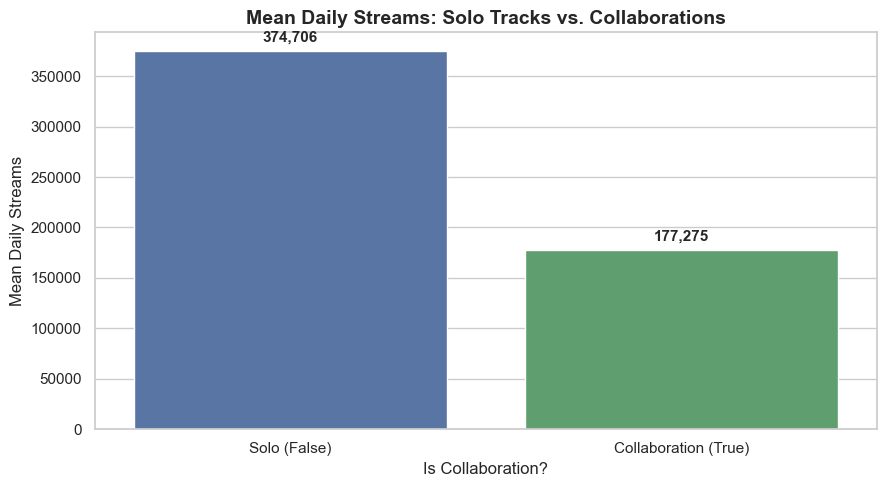

In [22]:
# Chart 1: Solo vs Collaboration Daily Streams Comparison (Warning-Free Fix)
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df,
    x="is_collaboration",
    y="daily_streams",
    hue="is_collaboration",  # Explicitly map hue to the x category
    estimator=np.mean,
    errorbar=None,
    palette=["#4C72B0", "#55A868"],
    legend=False,  # Suppress the redundant legend
)
plt.title(
    "Mean Daily Streams: Solo Tracks vs. Collaborations",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Is Collaboration?", fontsize=12)
plt.ylabel("Mean Daily Streams", fontsize=12)
plt.xticks([0, 1], ["Solo (False)", "Collaboration (True)"])

# Add labels on top of the bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("images/collab_vs_solo_streams.png", dpi=300)
plt.show()

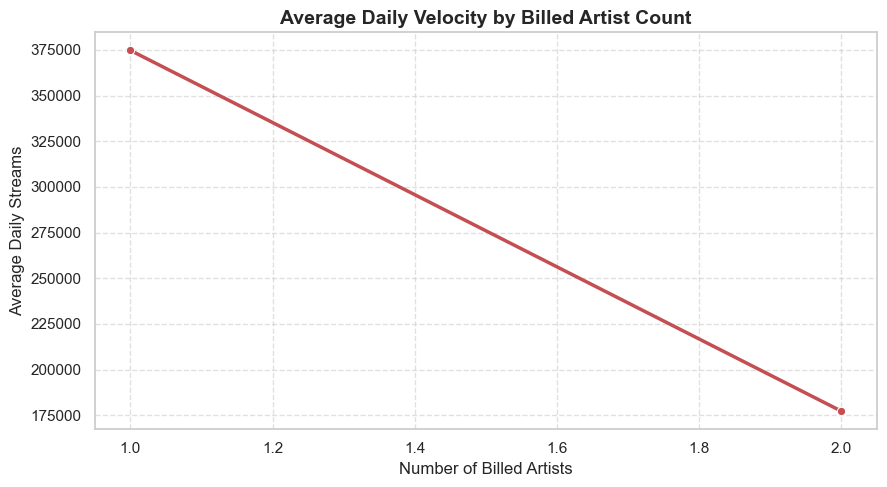

In [23]:
# Chart 2: Diminishing Returns of Artist Count
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=artist_count_summary,
    x="billed_artist_count",
    y="avg_daily_streams",
    marker="o",
    linewidth=2.5,
    color="#C44E52",
)
plt.title("Average Daily Velocity by Billed Artist Count", fontsize=14, fontweight="bold")
plt.xlabel("Number of Billed Artists", fontsize=12)
plt.ylabel("Average Daily Streams", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("images/artist_count_diminishing_returns.png", dpi=300)
plt.show()

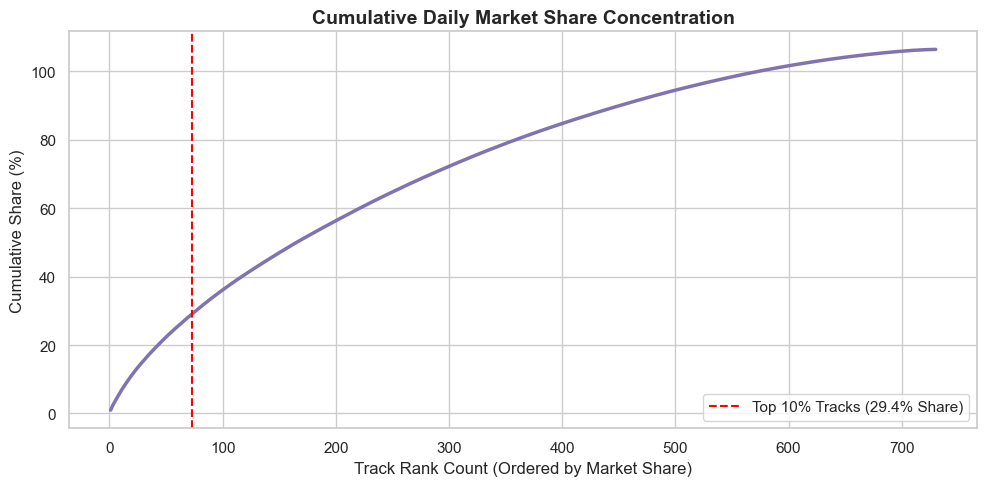

In [24]:
# Chart 3: Market Concentration Pareto Curve
plt.figure(figsize=(10, 5))
plt.plot(df_sorted.index + 1, df_sorted["cumulative_market_share"], color="#8172B0", linewidth=2.5)
plt.axvline(x=top_10_percent_cutoff, color="red", linestyle="--", label=f"Top 10% Tracks ({top_10_share:.1f}% Share)")
plt.title("Cumulative Daily Market Share Concentration", fontsize=14, fontweight="bold")
plt.xlabel("Track Rank Count (Ordered by Market Share)", fontsize=12)
plt.ylabel("Cumulative Share (%)", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/market_concentration.png", dpi=300)
plt.show()

### 6. TOP VIRAL MOMENTUM TARGETS

In [25]:
top_momentum = df.sort_values(by="rank_delta", ascending=False)[
    ["rank", "daily_streams_rank", "rank_delta", "track", "artist", "daily_streams", "spotify_streams_total"]
].head(10)

print("\n--- Step 4: Top 10 High-Momentum Catalog Targets ---")
print(top_momentum.to_string(index=False))


--- Step 4: Top 10 High-Momentum Catalog Targets ---
 rank  daily_streams_rank  rank_delta                        track             artist  daily_streams  spotify_streams_total
  621                  96         525       Tus Mentiras (En Vivo)      Moy Bobadilla         661275              116490412
  619                 126         493   Libu-Libong Buwan (Uuwian)       Kyle Raphael         563642              116709066
  581                 111         470       Sitaare (From "Ikkis")       Arijit Singh         604945              122029712
  687                 221         466                     Ishqa Ve        Zeeshan Ali         365504              106450961
  541                  86         455  Lihat Kebunku (Taman Bunga)           Aku Jeje         726423              127284277
  649                 218         431                         P.V.    Victor Mendivil         370727              113034812
  598                 175         423                    Gauchinha         DJ 